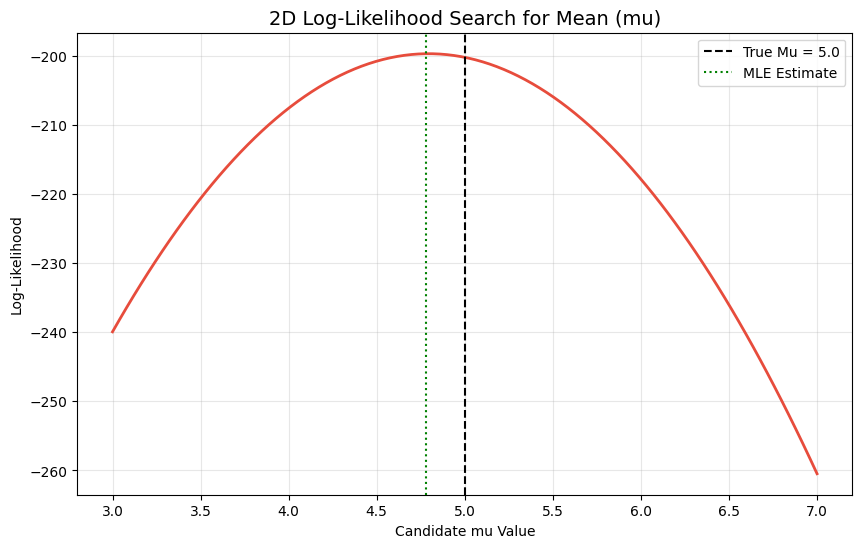

✅ 3D Asset saved: ../../../assets/55_mle_3d.png


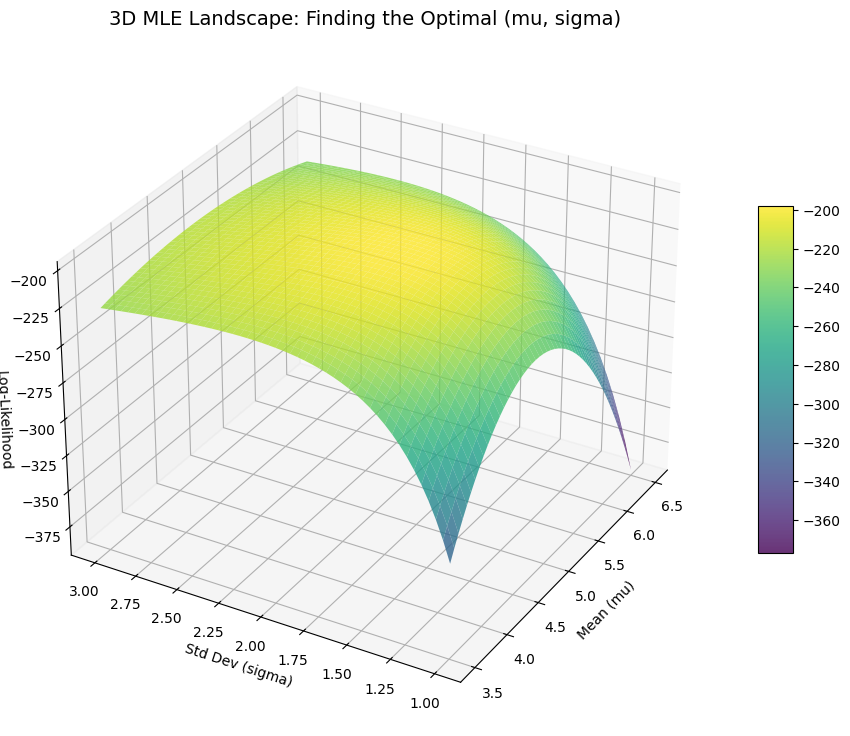

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os

def run_mle_master():
    # --- PROFESSIONAL PATH SETUP (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Generate synthetic data (The "Observed" Reality)
    true_mu = 5.0
    true_sigma = 2.0
    data = np.random.normal(true_mu, true_sigma, 100)

    # 2. Log-Likelihood Function for Normal Distribution
    def log_likelihood(mu, sigma, data):
        if sigma <= 0: return -np.inf
        return np.sum(norm.logpdf(data, mu, sigma))

    # --- 📸 ASSET 1: 2D LOG-LIKELIHOOD CURVE (55_mle_2d.png) ---
    mu_range = np.linspace(true_mu - 2, true_mu + 2, 100)
    ll_values = [log_likelihood(m, true_sigma, data) for m in mu_range]
    
    fig1 = plt.figure(figsize=(10, 6))
    plt.plot(mu_range, ll_values, color='#e74c3c', lw=2)
    plt.axvline(true_mu, color='black', linestyle='--', label=f'True Mu = {true_mu}')
    plt.axvline(mu_range[np.argmax(ll_values)], color='green', linestyle=':', label='MLE Estimate')
    
    plt.title("2D Log-Likelihood Search for Mean (mu)", fontsize=14)
    plt.xlabel("Candidate mu Value"); plt.ylabel("Log-Likelihood")
    plt.legend(); plt.grid(alpha=0.3)
    
    plt.savefig(os.path.join(asset_path, '55_mle_2d.png'), dpi=300)
    plt.show()

    # --- 📸 ASSET 2: 3D LIKELIHOOD SURFACE (55_mle_3d.png) ---
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    mu_space = np.linspace(true_mu - 1.5, true_mu + 1.5, 50)
    sigma_space = np.linspace(true_sigma - 1, true_sigma + 1, 50)
    MU, SIGMA = np.meshgrid(mu_space, sigma_space)
    
    # Calculate Z (Log-Likelihood) for each pair
    Z_ll = np.array([[log_likelihood(m, s, data) for m in mu_space] for s in sigma_space])

    surf = ax3d.plot_surface(MU, SIGMA, Z_ll, cmap='viridis', alpha=0.8, edgecolor='none')
    
    ax3d.set_title("3D MLE Landscape: Finding the Optimal (mu, sigma)", fontsize=14)
    ax3d.set_xlabel("Mean (mu)"); ax3d.set_ylabel("Std Dev (sigma)")
    ax3d.set_zlabel("Log-Likelihood")
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    ax3d.view_init(elev=30, azim=210)

    plt.savefig(os.path.join(asset_path, '55_mle_3d.png'), dpi=300)
    print(f"✅ 3D Asset saved: {asset_path}/55_mle_3d.png")
    plt.show()

if __name__ == "__main__":
    run_mle_master()
